In [1]:
print("Alzheimer's EEG Project")

Alzheimer's EEG Project


In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [3]:
print("MNE version:", mne.__version__)
print("NumPy version:", np.__version__)

MNE version: 1.13.2
NumPy version: 2.5.3


In [4]:
import sys

print("Python version:", sys.version)
print("Python location:", sys.executable)

Python version: 3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:37:13) [MSC v.1942 64 bit (AMD64)]
Python location: C:\Users\Saunak Das\miniconda3\envs\alzheimer_eeg\python.exe


In [5]:
from pathlib import Path

In [6]:
data_path = Path("../data")

In [7]:
print(data_path.exists())

True


In [8]:
for item in data_path.iterdir():
    print(item.name)

.datalad
.gitattributes
CHANGES
dataset_description.json
derivatives
participants.json
participants.tsv
README
sub-001
sub-002
sub-003
sub-004
sub-005
sub-006
sub-007
sub-008
sub-009
sub-010
sub-011
sub-012
sub-013
sub-014
sub-015
sub-016
sub-017
sub-018
sub-019
sub-020
sub-021
sub-022
sub-023
sub-024
sub-025
sub-026
sub-027
sub-028
sub-029
sub-030
sub-031
sub-032
sub-033
sub-034
sub-035
sub-036
sub-037
sub-038
sub-039
sub-040
sub-041
sub-042
sub-043
sub-044
sub-045
sub-046
sub-047
sub-048
sub-049
sub-050
sub-051
sub-052
sub-053
sub-054
sub-055
sub-056
sub-057
sub-058
sub-059
sub-060
sub-061
sub-062
sub-063
sub-064
sub-065
sub-066
sub-067
sub-068
sub-069
sub-070
sub-071
sub-072
sub-073
sub-074
sub-075
sub-076
sub-077
sub-078
sub-079
sub-080
sub-081
sub-082
sub-083
sub-084
sub-085
sub-086
sub-087
sub-088


In [9]:
import pandas as pd

In [10]:
participants = pd.read_csv(data_path / "participants.tsv", sep="\t")

In [11]:
participants.head()

,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-002,F,78,A,22
2,sub-003,M,70,A,14
3,sub-004,F,67,A,20
4,sub-005,M,70,A,22


In [12]:
participants.columns

Index(['participant_id', 'Gender', 'Age', 'Group', 'MMSE'], dtype='str')

In [13]:
participants["Group"].unique()

<StringArray>
['A', 'C', 'F']
Length: 3, dtype: str

In [14]:
participants["Group"].value_counts()

Group
A    36
C    29
F    23
Name: count, dtype: int64

In [15]:
subject_path = data_path / "sub-001"

In [16]:
for item in subject_path.iterdir():
    print(item.name)

eeg


In [17]:
eeg_path = subject_path / "eeg"

In [18]:
for item in eeg_path.iterdir():
    print(item.name)

sub-001_task-eyesclosed_channels.tsv
sub-001_task-eyesclosed_eeg.json
sub-001_task-eyesclosed_eeg.set


In [19]:
eeg_file = eeg_path / "sub-001_task-eyesclosed_eeg.set"

In [20]:
raw = mne.io.read_raw_eeglab(eeg_file, preload=False)

Reading C:\Users\Saunak Das\alzheimers-eeg-ml\notebooks\..\data\sub-001\eeg\sub-001_task-eyesclosed_eeg.set


In [21]:
print(raw)

<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~26 KiB, data not loaded>


In [22]:
print(raw.info["sfreq"])

500.0


In [23]:
print(raw.ch_names)

['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']


In [24]:
print(raw.info.keys())

dict_keys(['acq_pars', 'acq_stim', 'ctf_head_t', 'description', 'dev_head_t', 'dev_ctf_t', 'dig', 'experimenter', 'utc_offset', 'device_info', 'file_id', 'highpass', 'hpi_subsystem', 'kit_system_id', 'helium_info', 'line_freq', 'lowpass', 'meas_date', 'meas_id', 'proj_id', 'proj_name', 'subject_info', 'xplotter_layout', 'gantry_angle', 'bads', 'chs', 'comps', 'events', 'hpi_meas', 'hpi_results', 'projs', 'proc_history', 'custom_ref_applied', 'sfreq', 'ch_names', 'nchan'])


In [25]:
print(raw.info["nchan"])

19


In [26]:
print(raw.info["bads"])

[]


In [27]:
print("High-pass:", raw.info["highpass"])
print("Low-pass:", raw.info["lowpass"])

High-pass: 0.0
Low-pass: 250.0


In [28]:
print("Line frequency:", raw.info["line_freq"])

Line frequency: None


In [29]:
print(raw.info["meas_date"])

None


In [30]:
raw.get_data(start=0, stop=10).shape

(19, 10)

In [31]:
data = raw.get_data(start=0, stop=10)

In [32]:
print(data.shape)

(19, 10)


In [33]:
print(data)

[[-1.89892563e-04 -1.80419907e-04 -1.66992172e-04 -1.60205063e-04
  -1.59326157e-04 -1.54296860e-04 -1.71093735e-04 -1.83544907e-04
  -1.81542953e-04 -1.75927719e-04]
 [-1.41845688e-04 -1.37353500e-04 -1.35058578e-04 -1.32958969e-04
  -1.24462883e-04 -1.15820305e-04 -1.26074211e-04 -1.34326157e-04
  -1.36425766e-04 -1.33056625e-04]
 [-1.07373039e-04 -1.00048820e-04 -1.05761711e-04 -1.05322258e-04
  -1.04150383e-04 -9.73632736e-05 -1.04785149e-04 -1.16455070e-04
  -1.21972649e-04 -1.15576164e-04]
 [ 2.84667988e-05  3.22753906e-05  3.53515625e-05  3.80371094e-05
   4.11621094e-05  5.11718750e-05  4.57031212e-05  3.93066406e-05
   3.40820313e-05  3.92089844e-05]
 [-1.08447258e-04 -1.03369133e-04 -1.01953117e-04 -9.97558517e-05
  -9.84863205e-05 -8.97460937e-05 -9.71679611e-05 -1.04248039e-04
  -1.07617180e-04 -1.03955070e-04]
 [-3.64746094e-05 -3.36425781e-05 -2.98828125e-05 -2.70996075e-05
  -2.44628906e-05 -1.32812519e-05 -1.69921894e-05 -2.54394512e-05
  -3.12499981e-05 -2.50488262e-05

In [34]:
print(raw.get_montage())

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 19 channels>


In [35]:
positions = raw.get_montage().get_positions()["ch_pos"]

In [36]:
print(type(positions))
print(len(positions))

<class 'collections.OrderedDict'>
19


In [37]:
print(positions["Fp1"])

[-0.0294367  0.0839171 -0.00699  ]


In [38]:
print(raw.get_montage().get_positions()["coord_frame"])

head


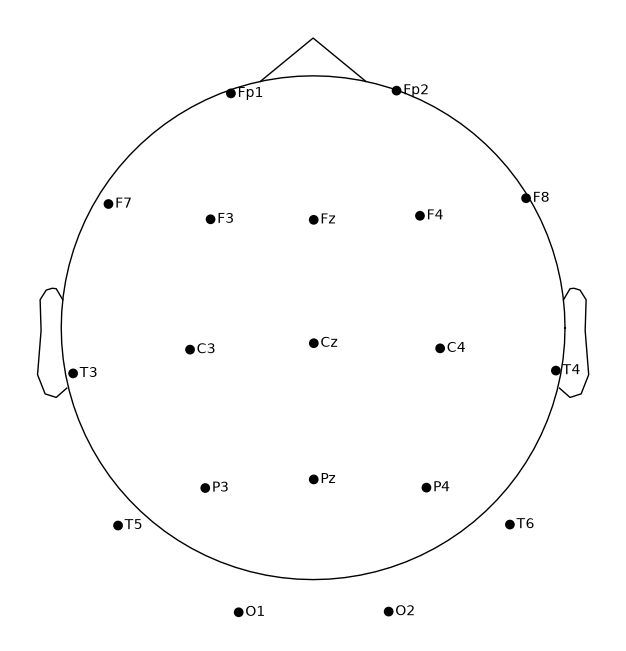

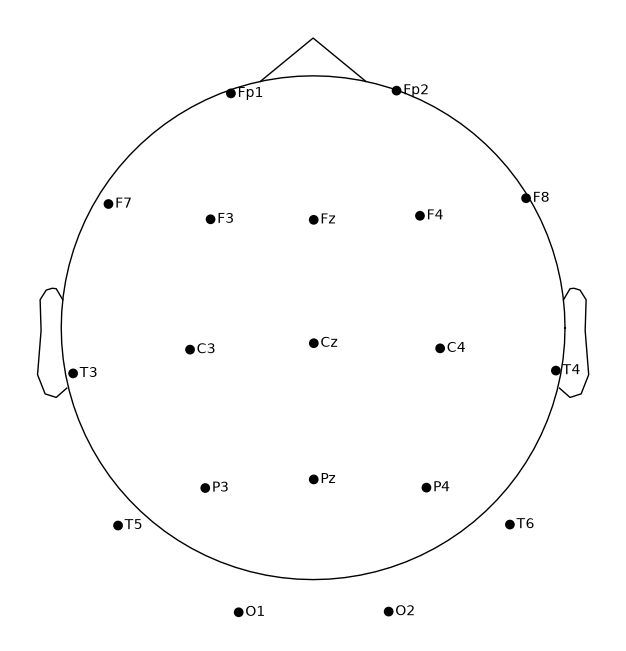

In [39]:
raw.get_montage().plot()

Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


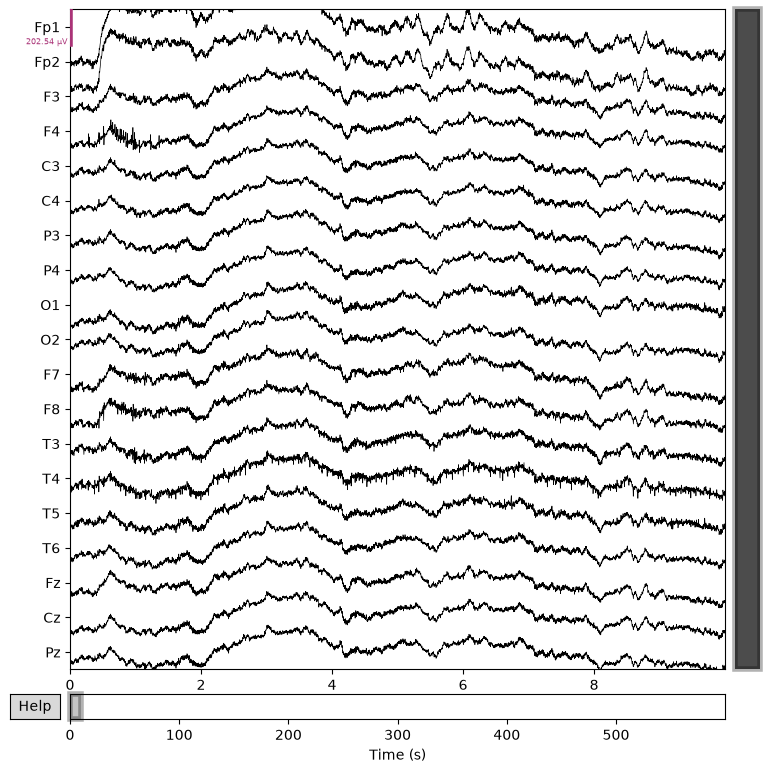

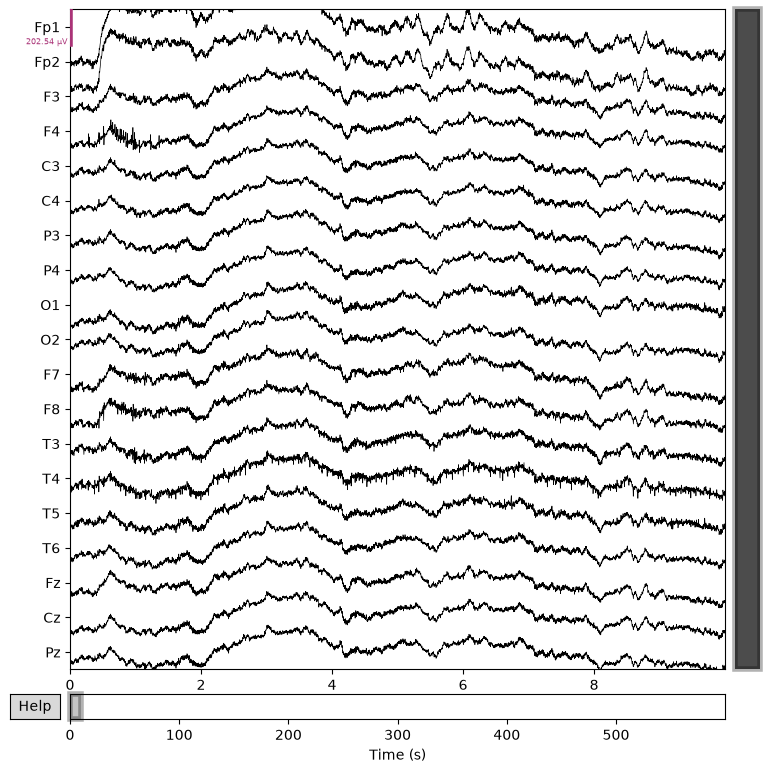

In [40]:
raw.plot(duration=10, n_channels=19, scalings="auto")

In [43]:
%matplotlib qt

C:\Users\Saunak Das\miniconda3\envs\alzheimer_eeg\Lib\site-packages\ipykernel\eventloops.py:158: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  el.exec() if hasattr(el, "exec") else el.exec_()


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


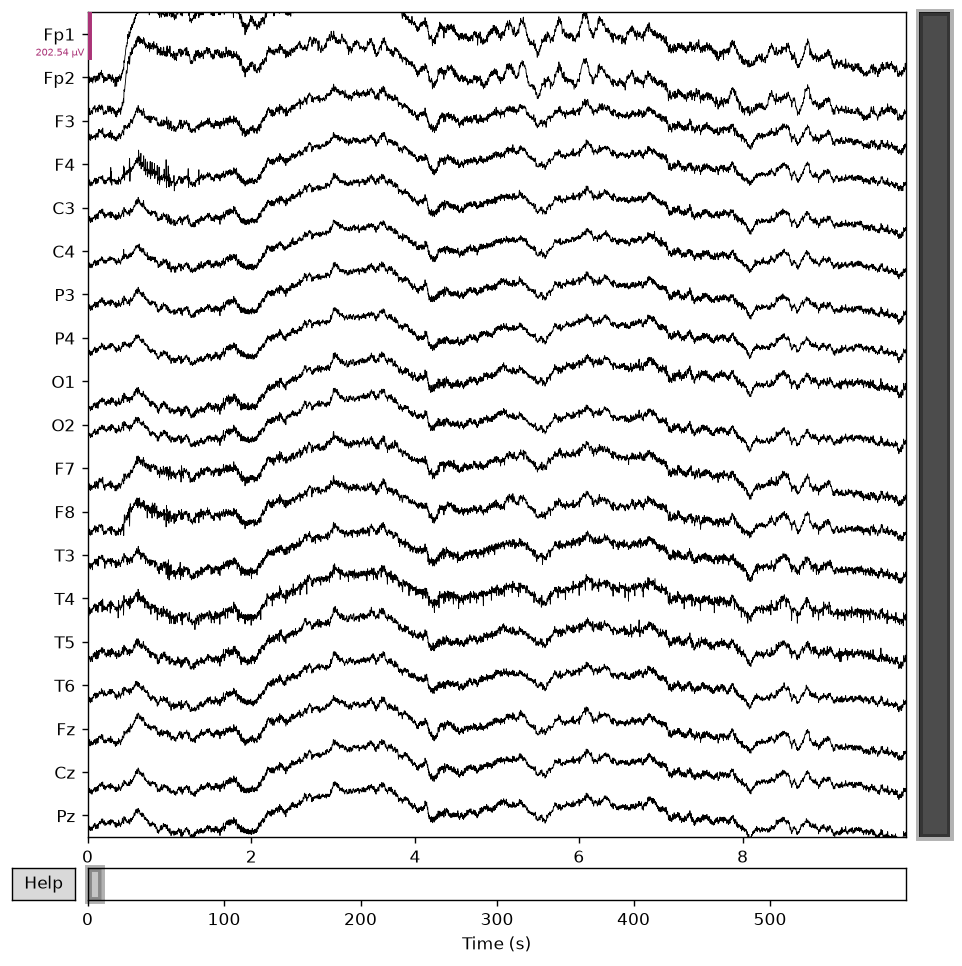

Channels marked as bad:
none


In [45]:
raw.plot(duration=10, n_channels=19, scalings="auto")

In [46]:
print(raw.get_channel_types())

['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']


In [47]:
data = raw.get_data()
print("Minimum:", data.min())
print("Maximum:", data.max())

Minimum: -0.00046611325073242185
Maximum: 0.0028796384277343747


In [48]:
print("Mean:", data.mean())
print("Standard deviation:", data.std())

Mean: 3.3488209181823e-05
Standard deviation: 0.00011126369084712183


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


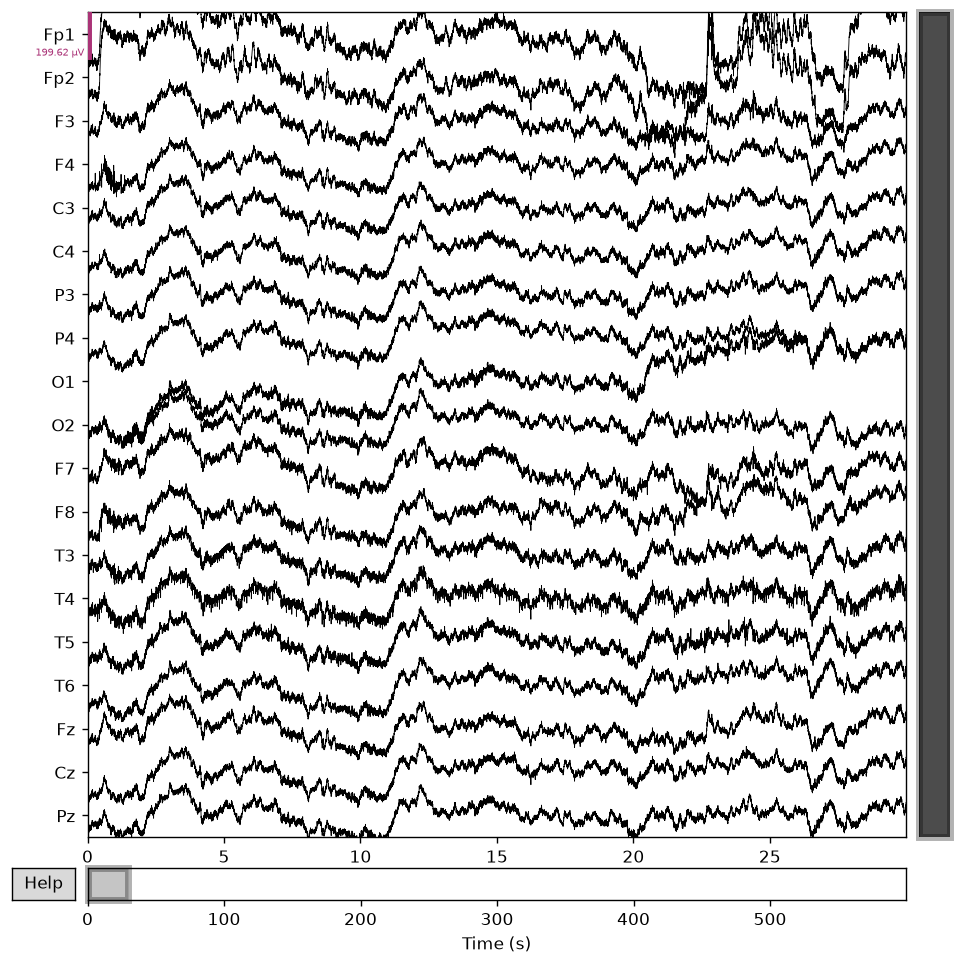

Channels marked as bad:
none


In [49]:
raw.plot(duration=30, n_channels=19, scalings="auto")

In [50]:
print(raw.info["custom_ref_applied"])

0 (FIFFV_MNE_CUSTOM_REF_OFF)


In [51]:
print(raw.info["chs"][0])

{'loc': array([-0.0294367,  0.0839171, -0.00699  ,  0.       ,  0.       ,
        0.       ,        nan,        nan,        nan,        nan,
              nan,        nan]), 'unit_mul': 0 (FIFF_UNITM_NONE), 'range': 1.0, 'cal': 1e-06, 'kind': 2 (FIFFV_EEG_CH), 'coil_type': 1 (FIFFV_COIL_EEG), 'unit': 107 (FIFF_UNIT_V), 'coord_frame': 4 (FIFFV_COORD_HEAD), 'ch_name': 'Fp1', 'scanno': 1, 'logno': 1}


In [52]:
print(raw.info["projs"])

[]


In [53]:
import json

with open(eeg_path / "sub-001_task-eyesclosed_eeg.json") as f:
    eeg_info = json.load(f)

print(eeg_info)

{'PowerLineFrequency': 50, 'SoftwareFilters': {'FilterDescription': {'Description': '0.4 - 50'}}, 'EEGPlacementScheme': '10-20', 'EEGReference': 'A1 A2', 'CapManufacturersModelName': 'EEG 2100', 'CapManufacturer': 'Nihon Kohden', 'InstitutionAddress': 'Arta, Greece', 'InstitutionalDepartmentName': 'Department of Informatics and Telecommunications', 'InstitutionName': 'University of Ioannina', 'TaskName': 'eyesclosed', 'EEGChannelCount': 19, 'RecordingType': 'continuous', 'RecordingDuration': 599.8, 'SamplingFrequency': 500, 'EOGChannelCount': 0, 'ECGChannelCount': 0, 'EMGChannelCount': 0}


In [54]:
raw_filtered = raw.copy()

In [56]:
raw_filtered.load_data()

Reading 0 ... 299899  =      0.000 ...   599.798 secs...


<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

In [57]:
print(raw_filtered.preload)

True


Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


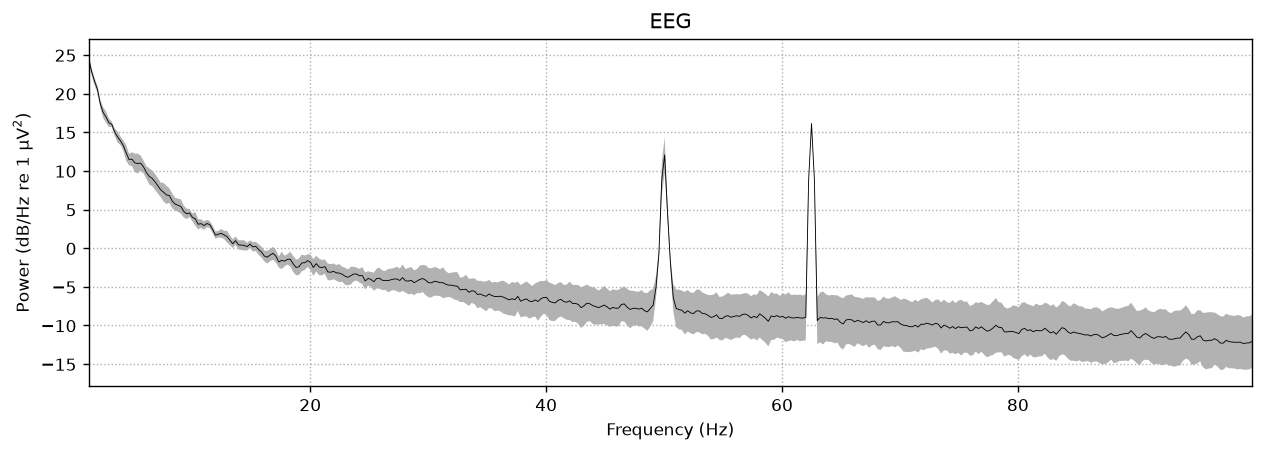

In [58]:
psd_1_100 = raw_filtered.compute_psd(
    method="welch",
    fmin=1,
    fmax=100
)

psd_1_100.plot(average=True)

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


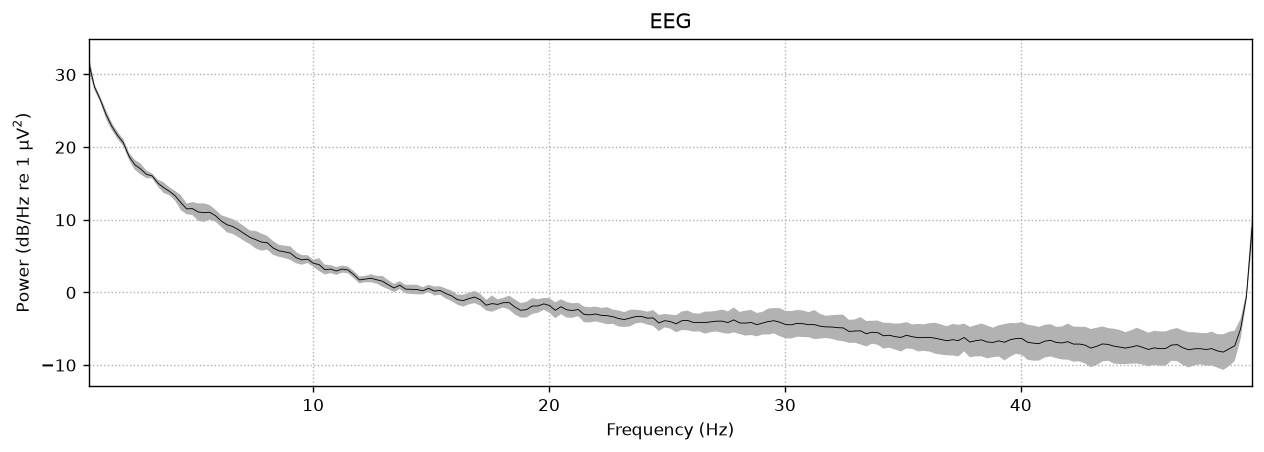

In [60]:
psd_04_50 = raw_filtered.compute_psd(
    method="welch",
    fmin=0.4,
    fmax=50
)

psd_04_50.plot(average=True)

In [61]:
print(psd_1_100.freqs[(psd_1_100.freqs >= 45) & (psd_1_100.freqs <= 55)])

[45.16601562 45.41015625 45.65429688 45.8984375  46.14257812 46.38671875
 46.63085938 46.875      47.11914062 47.36328125 47.60742188 47.8515625
 48.09570312 48.33984375 48.58398438 48.828125   49.07226562 49.31640625
 49.56054688 49.8046875  50.04882812 50.29296875 50.53710938 50.78125
 51.02539062 51.26953125 51.51367188 51.7578125  52.00195312 52.24609375
 52.49023438 52.734375   52.97851562 53.22265625 53.46679688 53.7109375
 53.95507812 54.19921875 54.44335938 54.6875     54.93164062]


In [62]:
idx = np.where((psd_1_100.freqs >= 45) & (psd_1_100.freqs <= 55))[0]

peak_idx = idx[np.argmax(psd_1_100.get_data()[:, idx].mean(axis=0))]

print("Peak frequency:", psd_1_100.freqs[peak_idx])

Peak frequency: 50.048828125
